# Data Cleaning And EDA
> In this notebook i clean and preform eda on our dataset



In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
# load dataset
sms = pd.read_csv('../Data/spam.csv',encoding='latin-1')
# view the data
sms.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [35]:
sms.shape
# 5572 rows and 5 columsn


(5572, 5)

In [36]:
sms.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 217.8 KB


In [37]:
sms.isnull().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

- Drop cloumns   Unnamed: 2 ,Unnamed: 3 ,Unnamed: 4
> casue maxisum values are  null values

In [38]:
sms.columns

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='str')

In [39]:
# drop the columns 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4 and make parmatnt change in sms data
sms.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'],inplace=True)

# check
sms.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [40]:
# changing the columns name for better understanding
# v1-> output and v2 -> massages
sms.rename(columns={'v1':'output','v2':'messages'},inplace=True)

# chec
sms.columns

Index(['output', 'messages'], dtype='str')

In [41]:
sms['output'].value_counts()

output
ham     4825
spam     747
Name: count, dtype: int64

C:\Users\Avik Maity\AppData\Local\Temp\ipykernel_1804\730107955.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='output', data=sms,palette='Set2')


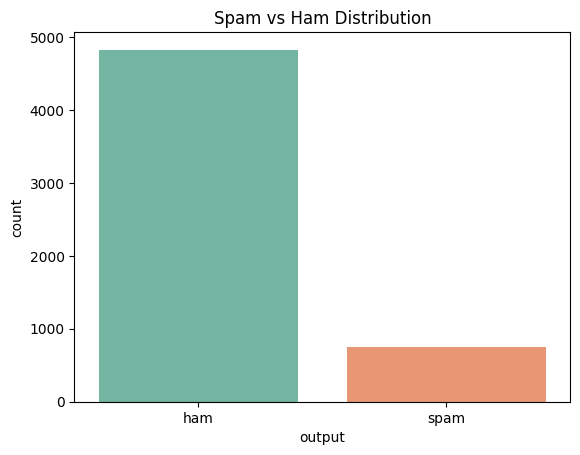

In [42]:
sns.countplot(x='output', data=sms,palette='Set2')
plt.title("Spam vs Ham Distribution")
plt.show();

the output columns quite impbalenc  to prent this we take the serval steps:


## 1. Train baseline (Naive Bayes)

### Test Preprocessing

In [43]:
# encode the output columns
# Hamp ->0
# sapm ->1
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
sms['output'] = le.fit_transform(sms['output'])

# check 
sms.value_counts()

output  messages                                                                                                                                                                           
0       Sorry, I'll call later                                                                                                                                                                 30
        I cant pick the phone right now. Pls send a message                                                                                                                                    12
        Ok...                                                                                                                                                                                  10
1       Please call our customer service representative on FREEPHONE 0808 145 4742 between 9am-11pm as you have WON a guaranteed å£1000 cash or å£5000 prize!                                   4
0       Wen ur lovable bcums angry w

In [44]:
## Lower the text in massages colums
sms['messages'] = sms['messages'].str.lower()
# check 
sms['messages'].head()

0    go until jurong point, crazy.. available only ...
1                        ok lar... joking wif u oni...
2    free entry in 2 a wkly comp to win fa cup fina...
3    u dun say so early hor... u c already then say...
4    nah i don't think he goes to usf, he lives aro...
Name: messages, dtype: str

In [45]:
sms.head()

,output,messages
0,0,"go until jurong point, crazy.. available only ..."
1,0,ok lar... joking wif u oni...
2,1,free entry in 2 a wkly comp to win fa cup fina...
3,0,u dun say so early hor... u c already then say...
4,0,"nah i don't think he goes to usf, he lives aro..."


In [46]:
# step two 
import re
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')


[nltk_data] Downloading package stopwords to C:\Users\Avik
[nltk_data]     Maity\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [47]:
from bs4 import BeautifulSoup
# 1. lowercase
sms['messages'] = sms['messages'].str.lower()
# Remove the stopswords
sms['messages'] =sms['messages'] .apply(lambda x:" ".join([y for y in x.split() if y not in stopwords.words('english')]))

# 3. remove urls
sms['messages'] = sms['messages'].apply(lambda x: re.sub(r'http\S+', '', x))

# 4. remove special characters
sms['messages'] = sms['messages'].apply(lambda x: re.sub(r'[^a-zA-Z0-9\s]', '', x))

In [48]:
import nltk
nltk.download('wordnet')
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()

def lemma_words(text):
    return " ".join([lemmatizer.lemmatize(word,pos='v') for word in text.split()])

sms['messages'] = sms['messages'] .apply(lemma_words)

[nltk_data] Downloading package wordnet to C:\Users\Avik
[nltk_data]     Maity\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [49]:
# split the data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(sms['messages'] , sms['output'], test_size=0.33, random_state=42)

